<a href="https://colab.research.google.com/github/hadri1-bisch/real-data-proect/blob/main/visitor_insight.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

analyse de l'evoluition "carte de transport"


In [ ]:
import numpy as np
import pandas as pd
from google.colab import files
import io

In [ ]:
uploaded = files.upload("carte_transport.csv")
filename = list(uploaded.keys())[0]
raw = uploaded[filename].decode('utf-8').splitlines()
for line in raw[:10]:
    print(line)

Saving carte_transport.csv to carte_transport.csv/carte_transport (5).csv
,jan,Févr,mars,avr,mai,juin,juil,août,sept,oct,nov,déc,Total
Cartes de transport 2022,10 604,17 356,24 904,30 985,39 836,44 367,45 897,43 671,43 079,18 632,28 008,34 091,381 430
Cartes de transport 2025,22 851,25 517,32 324,36 789,48 858,48 737,49 832,51 434,46 556,40 997,36 607,33 024,473 526
Cartes de transport 2024,20 415,24 217,32 833,35 199,44 798,45 575,47 605,49 572,47 069,41 657,37 026,31 688,457 654
Cartes de transport 2023,21 067,22 552,30 590,34 188,44 414,44 479,47 384,46 056,45 106,38 311,34 069,29 431,437 647
Évolution en % 2022 - 2025,-53,6%,-32,0%,-23,0%,-15,8%,-18,5%,-9,0%,-7,9%,-15,1%,-7,5%,-54,6%,-23,5%,3,2%,-19,4%
Évolution en % 2022 - 2024,-48,1%,-28,3%,-24,1%,-12,0%,-11,1%,-2,7%,-3,6%,-11,9%,-8,5%,-55,3%,-24,4%,7,6%,-16,7%
Évolution en % 2022 - 2023,-49,7%,-23,0%,-18,6%,-9,4%,-10,3%,-0,3%,-3,1%,-5,2%,-4,5%,-51,4%,-17,8%,15,8%,-12,8%
Évolution en % 2025 - 2024,11,9%,5,4%,-1,6%,4,5%,9,1%,6,9%,

In [ ]:


# --- Données ---
raw_data = {
    "annee": [2022, 2023, 2024, 2025],
    "jan":  [10604, 21067, 20415, 22851],
    "feb":  [17356, 22552, 24217, 25517],
    "mar":  [24904, 30590, 32833, 32324],
    "apr":  [30985, 34188, 35199, 36789],
    "may":  [39836, 44414, 44798, 48858],
    "jun":  [44367, 44479, 45575, 48737],
    "jul":  [45897, 47384, 47605, 49832],
    "aug":  [43671, 46056, 49572, 51434],
    "sep":  [43079, 45106, 47069, 46556],
    "oct":  [18632, 38311, 41657, 40997],
    "nov":  [28008, 34069, 37026, 36607],
    "dec":  [34091, 29431, 31688, 33024],
}

mois_order = ["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"]

df = pd.DataFrame(raw_data)

# --- Format long, trié par mois puis année ---
df_long = df.melt(id_vars="annee", var_name="mois", value_name="cartes")
df_long["mois"] = pd.Categorical(df_long["mois"], categories=mois_order, ordered=True)
df_long = df_long.sort_values(["mois", "annee"]).reset_index(drop=True)

print("=== Tendances mensuelles au fil des années ===")
print(df_long.to_string(index=False))
print()

# --- Pivot : lignes = mois, colonnes = années (lecture facile) ---
df_pivot = df_long.pivot(index="mois", columns="annee", values="cartes")
df_pivot.index.name = "mois"

# Évolution % d'une année à l'autre, par mois
df_pivot["evol_22_23"] = ((df_pivot[2023] - df_pivot[2022]) / df_pivot[2022] * 100).round(1)
df_pivot["evol_23_24"] = ((df_pivot[2024] - df_pivot[2023]) / df_pivot[2023] * 100).round(1)
df_pivot["evol_24_25"] = ((df_pivot[2025] - df_pivot[2024]) / df_pivot[2024] * 100).round(1)

print("=== Pivot : volumes + évolutions % par mois ===")
print(df_pivot.to_string())

=== Tendances mensuelles au fil des années ===
 annee mois  cartes
  2022  jan   10604
  2023  jan   21067
  2024  jan   20415
  2025  jan   22851
  2022  feb   17356
  2023  feb   22552
  2024  feb   24217
  2025  feb   25517
  2022  mar   24904
  2023  mar   30590
  2024  mar   32833
  2025  mar   32324
  2022  apr   30985
  2023  apr   34188
  2024  apr   35199
  2025  apr   36789
  2022  may   39836
  2023  may   44414
  2024  may   44798
  2025  may   48858
  2022  jun   44367
  2023  jun   44479
  2024  jun   45575
  2025  jun   48737
  2022  jul   45897
  2023  jul   47384
  2024  jul   47605
  2025  jul   49832
  2022  aug   43671
  2023  aug   46056
  2024  aug   49572
  2025  aug   51434
  2022  sep   43079
  2023  sep   45106
  2024  sep   47069
  2025  sep   46556
  2022  oct   18632
  2023  oct   38311
  2024  oct   41657
  2025  oct   40997
  2022  nov   28008
  2023  nov   34069
  2024  nov   37026
  2025  nov   36607
  2022  dec   34091
  2023  dec   29431
  2024  dec  

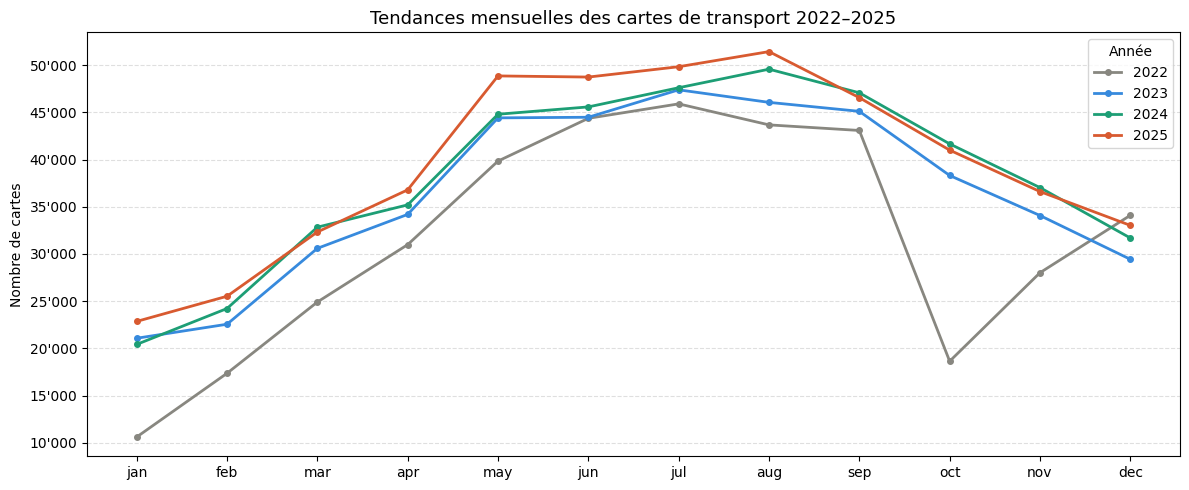

In [ ]:
import matplotlib.pyplot as plt

# df_pivot est déjà en mémoire depuis ton script précédent
# On plot directement les colonnes des années

couleurs = {"2022": "#888780", "2023": "#378ADD", "2024": "#1D9E75", "2025": "#D85A30"}

fig, ax = plt.subplots(figsize=(12, 5))

for annee in [2022, 2023, 2024, 2025]:
    ax.plot(df_pivot.index, df_pivot[annee], marker="o", label=str(annee),
            color=couleurs[str(annee)], linewidth=2, markersize=4)

ax.set_title("Tendances mensuelles des cartes de transport 2022–2025", fontsize=13)
ax.set_ylabel("Nombre de cartes")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}".replace(",", "'")))
ax.legend(title="Année")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("graphe_tendances.png", dpi=150)
plt.show()

idée rendre carte de transport plus attractive, plus marketer?


In [ ]:
# upload
uploaded = files.upload("precipitation 2014-2025.xls")

# récupérer le nom du fichier
filename = list(uploaded.keys())[0]

# lire le fichier Excel
df_météo = pd.read_excel(io.BytesIO(uploaded[filename]))

df_météo

Saving precipitation 2014-2025.xls to precipitation 2014-2025.xls/precipitation 2014-2025 (1).xls


,année,jan,Févr,mars,avr,mai,juin,juil,août,sept,oct,nov,déc
0,2025,209.0,38.7,61.6,64.2,130.0,101.1,151.3,143.4,201.9,177.2,176.3,25.0
1,2024,119.0,70.6,118.7,112.4,235.4,166.9,157.8,118.8,215.8,152.9,120.8,136.3
2,2023,97.1,10.0,336.4,193.0,123.8,95.7,168.3,188.7,67.6,162.7,295.0,228.2
3,2022,58.7,99.8,20.9,120.6,54.7,140.9,70.6,50.3,206.1,77.9,140.7,141.3
4,2021,220.9,65.4,98.2,79.4,254.1,107.4,252.4,151.4,71.5,78.8,85.4,177.8
5,2020,57.0,172.5,107.1,40.0,126.8,149.7,94.6,142.5,94.9,217.2,35.9,160.8
6,2019,104.7,61.5,117.9,85.8,121.0,109.3,105.8,132.6,89.7,190.7,187.2,204.5
7,2018,238.8,76.3,133.2,40.9,120.7,64.1,71.5,69.1,49.3,57.4,69.9,204.7
8,2017,74.4,87.1,99.6,67.7,110.4,92.8,101.1,105.6,87.8,51.3,148.4,212.1
9,2016,241.9,184.9,98.2,147.4,206.8,145.0,137.7,94.9,91.9,84.4,122.4,0.9


In [ ]:
df_météo.columns

Index(['année', 'jan', 'Févr', 'mars', 'avr', 'mai', 'juin', 'juil', 'août',
       'sept', 'oct', 'nov', 'déc'],
      dtype='object')

In [ ]:
df_météo = df_météo.set_index("année").T
df_météo

année,2025,2024,2023,2022,2021,2020,2019,2018,2017,2016,2015,2014
jan,209.0,119.0,97.1,58.7,220.9,57.0,104.7,238.8,74.4,241.9,146.2,129.2
Févr,38.7,70.6,10.0,99.8,65.4,172.5,61.5,76.3,87.1,184.9,74.7,152.5
mars,61.6,118.7,336.4,20.9,98.2,107.1,117.9,133.2,99.6,98.2,98.9,48.5
avr,64.2,112.4,193.0,120.6,79.4,40.0,85.8,40.9,67.7,147.4,102.1,75.2
mai,130.0,235.4,123.8,54.7,254.1,126.8,121.0,120.7,110.4,206.8,172.1,136.0
juin,101.1,166.9,95.7,140.9,107.4,149.7,109.3,64.1,92.8,145.0,60.6,94.9
juil,151.3,157.8,168.3,70.6,252.4,94.6,105.8,71.5,101.1,137.7,57.7,271.9
août,143.4,118.8,188.7,50.3,151.4,142.5,132.6,69.1,105.6,94.9,101.5,146.1
sept,201.9,215.8,67.6,206.1,71.5,94.9,89.7,49.3,87.8,91.9,170.4,57.3
oct,177.2,152.9,162.7,77.9,78.8,217.2,190.7,57.4,51.3,84.4,73.7,100.6


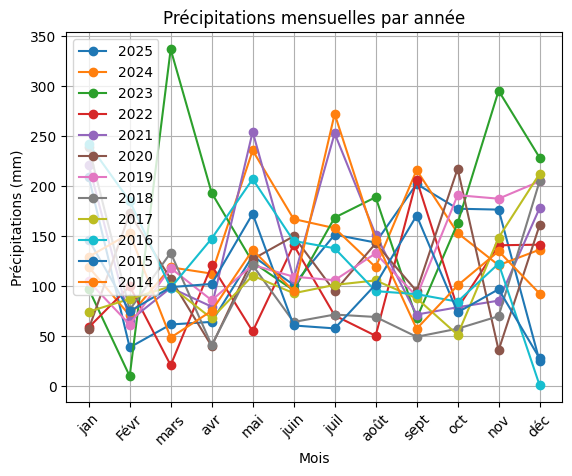

In [ ]:
import matplotlib.pyplot as plt

# convertir en float si besoin
df_météo = df_météo.astype(float)

# plot
plt.figure()

for col in df_météo.columns:
    plt.plot(df_météo.index, df_météo[col], marker='o', label=col)

plt.title("Précipitations mensuelles par année")
plt.xlabel("Mois")
plt.ylabel("Précipitations (mm)")
plt.xticks(rotation=45)
plt.legend()
plt.grid()

plt.show()

moyenne precipitaiton par moi

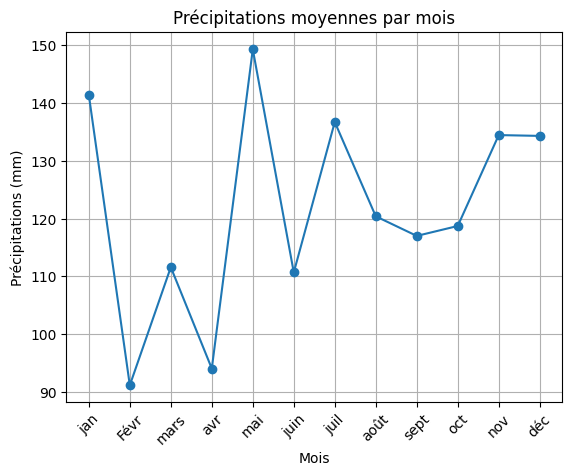

In [ ]:
import matplotlib.pyplot as plt

# moyenne par mois
df_moyenne = df_météo.astype(float).mean(axis=1)

plt.figure()
plt.plot(df_moyenne.index, df_moyenne.values, marker='o')

plt.title("Précipitations moyennes par mois")
plt.xlabel("Mois")
plt.ylabel("Précipitations (mm)")
plt.xticks(rotation=45)
plt.grid()

plt.show()

min max par mois

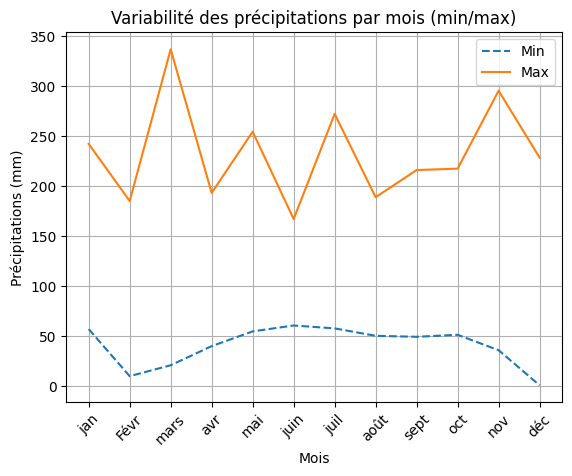

In [ ]:
import matplotlib.pyplot as plt

df = df_météo.astype(float)

df_min = df.min(axis=1)
df_max = df.max(axis=1)

plt.figure()

plt.plot(df.index, df_min, linestyle='--', label='Min')
plt.plot(df.index, df_max, linestyle='-', label='Max')

plt.title("Variabilité des précipitations par mois (min/max)")
plt.xlabel("Mois")
plt.ylabel("Précipitations (mm)")
plt.xticks(rotation=45)
plt.legend()
plt.grid()

plt.show()